<a href="https://colab.research.google.com/github/AlperYildirim1/Earthquake-Ruptures/blob/main/PytorchUnetResnet101_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile
import os

# Dosya yolu
zip_file_path = '/content/drive/MyDrive/UnetTrain/crack_segmentation_dataset.zip'
extract_to = '/content/data'

# Zip dosyasını aç
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Dosya başarıyla çıkartıldı.")


Dosya başarıyla çıkartıldı.


In [ ]:

def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )


def up_conv(in_channels, out_channels):
    return nn.ConvTranspose2d(
        in_channels, out_channels, kernel_size=2, stride=2
    )


In [ ]:
import os
from PIL import Image
from torch.utils.data.dataset import Dataset
from torchvision import transforms

class CrackDataset(Dataset):
    def __init__(self, root_path, test=False):
        self.root_path = root_path
        if test:
            # For testing dataset
            self.images = sorted([os.path.join(root_path, "test/images", i)
                                  for i in os.listdir(os.path.join(root_path, "test/images"))
                                  if os.path.isfile(os.path.join(root_path, "test/images", i))])
            self.masks = sorted([os.path.join(root_path, "test/masks", i)
                                 for i in os.listdir(os.path.join(root_path, "test/masks"))
                                 if os.path.isfile(os.path.join(root_path, "test/masks", i))])
        else:
            # For training dataset
            self.images = sorted([os.path.join(root_path, "train/images", i)
                                  for i in os.listdir(os.path.join(root_path, "train/images"))
                                  if os.path.isfile(os.path.join(root_path, "train/images", i))])
            self.masks = sorted([os.path.join(root_path, "train/masks", i)
                                 for i in os.listdir(os.path.join(root_path, "train/masks"))
                                 if os.path.isfile(os.path.join(root_path, "train/masks", i))])

        self.transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor()])

    def __getitem__(self, index):
        img = Image.open(self.images[index]).convert("RGB")
        mask = Image.open(self.masks[index]).convert("L")

        return self.transform(img), self.transform(mask)

    def __len__(self):
        return len(self.images)


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet101

class Unet(nn.Module):
    """Deep Unet with ResNet50, ResNet101 or ResNet152 encoder.
    """

    def __init__(self, encoder, *, pretrained=False, out_channels=2):
        super().__init__()
        self.encoder = encoder(pretrained=pretrained)
        self.encoder_layers = list(self.encoder.children())

        self.block1 = nn.Sequential(*self.encoder_layers[:3])
        self.block2 = nn.Sequential(*self.encoder_layers[3:5])
        self.block3 = self.encoder_layers[5]
        self.block4 = self.encoder_layers[6]
        self.block5 = self.encoder_layers[7]

        self.up_conv6 = up_conv(2048, 512)
        self.conv6 = double_conv(512 + 1024, 512)
        self.up_conv7 = up_conv(512, 256)
        self.conv7 = double_conv(256 + 512, 256)
        self.up_conv8 = up_conv(256, 128)
        self.conv8 = double_conv(128 + 256, 128)
        self.up_conv9 = up_conv(128, 64)
        self.conv9 = double_conv(64 + 64, 64)
        self.up_conv10 = up_conv(64, 32)
        self.conv10 = nn.Conv2d(32, out_channels, kernel_size=1)

        if not pretrained:
            self._weights_init()

    def _weights_init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        block1 = self.block1(x)
        block2 = self.block2(block1)
        block3 = self.block3(block2)
        block4 = self.block4(block3)
        block5 = self.block5(block4)

        x = self.up_conv6(block5)
        x = torch.cat([x, block4], dim=1)
        x = self.conv6(x)

        x = self.up_conv7(x)
        x = torch.cat([x, block3], dim=1)
        x = self.conv7(x)

        x = self.up_conv8(x)
        x = torch.cat([x, block2], dim=1)
        x = self.conv8(x)

        x = self.up_conv9(x)
        x = torch.cat([x, block1], dim=1)
        x = self.conv9(x)

        x = self.up_conv10(x)
        x = self.conv10(x)

        return x

In [ ]:
import torch
from torch import optim, nn
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import os
import logging
import torchvision.models as models

if __name__ == "__main__":
    LEARNING_RATE = 1e-4
    BATCH_SIZE = 8
    EPOCHS = 5
    DATA_PATH = "/content/data/crack_segmentation_dataset"
    MODEL_SAVE_PATH = "/content/save"
    model_pth = "/content/modelpath/model.pth"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_dataset = CrackDataset(DATA_PATH)

    generator = torch.Generator().manual_seed(42)
    train_dataset = CrackDataset(DATA_PATH)
    val_dataset = CrackDataset(DATA_PATH, test=True)

    train_dataloader = DataLoader(dataset=train_dataset,
                                batch_size=BATCH_SIZE,
                                shuffle=True)
    val_dataloader = DataLoader(dataset=val_dataset,
                                batch_size=BATCH_SIZE,
                                shuffle=True)
    encoder = models.resnet101
    model = Unet(encoder=encoder, pretrained=True, out_channels=1).to(device)

    # Load the saved state dict
    model.load_state_dict(torch.load(model_pth, map_location=device))

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.BCEWithLogitsLoss()


    for epoch in tqdm(range(EPOCHS), desc="Epochs", unit="epoch", leave=True, dynamic_ncols=True):
        model.train()
        train_running_loss = 0

        for idx, img_mask in enumerate(tqdm(train_dataloader, desc="Training", unit="batch", leave=True, dynamic_ncols=True, position=0, mininterval=1)):
            img = img_mask[0].float().to(device)
            mask = img_mask[1].float().to(device)

            y_pred = model(img)
            optimizer.zero_grad()
            loss = criterion(y_pred, mask)
            train_running_loss += loss.item()

            loss.backward()
            optimizer.step()

        train_loss = train_running_loss / (idx + 1)

        # Validation loop
        model.eval()
        val_running_loss = 0
        with torch.no_grad():
            for idx, img_mask in enumerate(tqdm(val_dataloader, desc="Validation", unit="batch", leave=True, dynamic_ncols=True, position=0, mininterval=1)):
                img = img_mask[0].float().to(device)
                mask = img_mask[1].float().to(device)

                y_pred = model(img)
                loss = criterion(y_pred, mask)

                val_running_loss += loss.item()

            val_loss = val_running_loss / (idx + 1)

        # Log epoch losses
        logging.info("-" * 30)
        logging.info(f"Train Loss EPOCH {epoch + 1}: {train_loss:.4f}")
        logging.info(f"Valid Loss EPOCH {epoch + 1}: {val_loss:.4f}")
        logging.info("-" * 30)


# Ensure the directory exists before saving
MODEL_SAVE_PATH = "/content/modelpath"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)  # Create the directory if it doesn't exist

torch.save(model.state_dict(), os.path.join(MODEL_SAVE_PATH, 'model.pth')) # Save with .pth extension and inside directory

In [ ]:
import torch
from torch import optim, nn
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import os # Import the os module

# Ensure the directory exists before saving
MODEL_SAVE_PATH = "/content/last"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)  # Create the directory if it doesn't exist

torch.save(model.state_dict(), os.path.join(MODEL_SAVE_PATH, 'last.pth')) # Save with .pth extension and inside directory

<ipython-input-15-d3cba7cef48b>:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_pth, map_location=torch.device(device)))


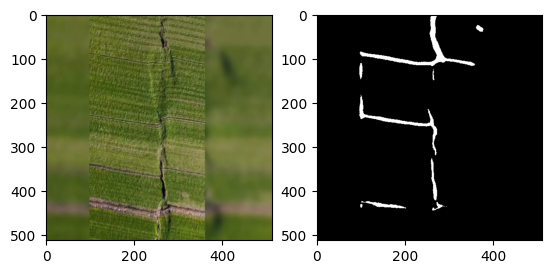

In [ ]:
import torch
from torch import optim, nn
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import os # Import the os module
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt # Import matplotlib
import torchvision.models as models

def single_image_inference(image_pth, model_pth, device):
    encoder = models.resnet101
    model = Unet(encoder=encoder, pretrained=True, out_channels=1).to(device)
    model.load_state_dict(torch.load(model_pth, map_location=torch.device(device)))

    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor()])

    img = transform(Image.open(image_pth)).float().to(device)
    img = img.unsqueeze(0)

    pred_mask = model(img)
    img = img.squeeze(0).cpu().detach()
    img = img.permute(1, 2, 0)

    pred_mask = pred_mask.squeeze(0).cpu().detach()
    pred_mask = pred_mask.permute(1, 2, 0)
    pred_mask[pred_mask < 0]=0
    pred_mask[pred_mask > 0]=1

    fig = plt.figure()
    for i in range(1, 3):
        fig.add_subplot(1, 2, i)
        if i == 1:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(pred_mask, cmap="gray")
    plt.show()


if __name__ == "__main__":
    SINGLE_IMG_PATH = "/content/fault.png"
    #DATA_PATH = "./data"
    MODEL_PATH = "/content/drive/MyDrive/PtorchUnet/last.pth"

    device = "cuda" if torch.cuda.is_available() else "cpu"
    #pred_show_image_grid(DATA_PATH, MODEL_PATH, device)
    single_image_inference(SINGLE_IMG_PATH, MODEL_PATH, device)

<ipython-input-14-de65a2ff3fea>:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_pth, map_location=device))


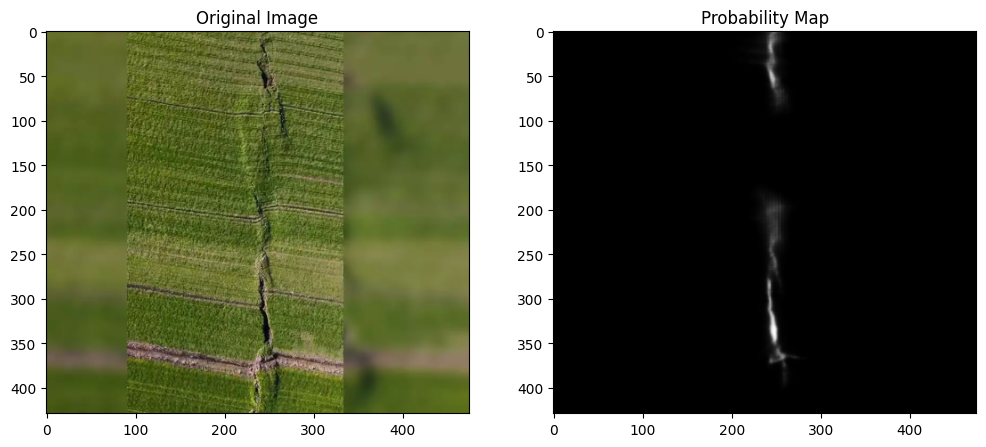

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


def single_image_inference_prob(image_pth, model_pth, device):
    # Load the model and set it to evaluation mode
    encoder = models.resnet101

    # Load the model and set it to evaluation mode
    # Pass the encoder to the Unet constructor
    model = Unet(encoder=encoder, pretrained=True, out_channels=1).to(device)
    model.load_state_dict(torch.load(model_pth, map_location=device))
    model.eval()

    # Transformation for the input image
    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor()
    ])

    # Load and transform the image
    img = transform(Image.open(image_pth)).float().to(device)
    img = img.unsqueeze(0)  # Add batch dimension

    # Predict the mask (output is in logits, so we apply sigmoid to get probabilities)
    with torch.no_grad():
        pred_mask = model(img)
        pred_mask = F.sigmoid(pred_mask).squeeze(0).cpu().numpy()  # Convert to probability map

    # Resize the probability map back to the original image dimensions
    original_img = Image.open(image_pth)
    pred_mask_resized = np.array(Image.fromarray(pred_mask[0]).resize(original_img.size, resample=Image.BILINEAR))

    # Display the original image and the probability map
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(original_img, cmap="gray")
    axs[0].set_title("Original Image")
    axs[1].imshow(pred_mask_resized, cmap="gray")
    axs[1].set_title("Probability Map")
    plt.show()

    return pred_mask_resized

if __name__ == "__main__":
    SINGLE_IMG_PATH = "/content/fault.png"
    MODEL_PATH = "/content/drive/MyDrive/PtorchUnet/last.pth"
    device = "cuda" if torch.cuda.is_available() else "cpu"

    probability_map = single_image_inference_prob(SINGLE_IMG_PATH, MODEL_PATH, device)


<ipython-input-16-cc621b440bd1>:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_pth, map_location=device))


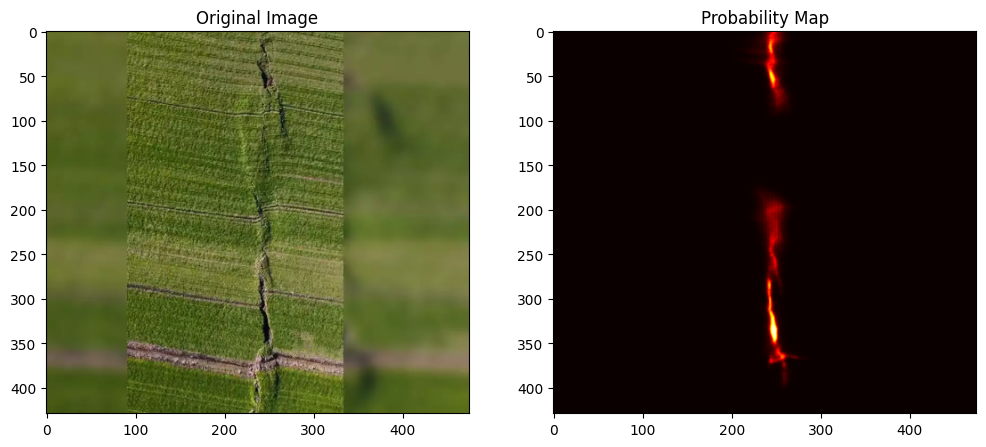

In [ ]:
def single_image_inference_prob(image_pth, model_pth, device):
    encoder = models.resnet101
    model = Unet(encoder=encoder, pretrained=True, out_channels=1).to(device)
    model.load_state_dict(torch.load(model_pth, map_location=device))
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor()
    ])
    img = transform(Image.open(image_pth)).float().to(device)
    img = img.unsqueeze(0)  # Add batch dimension

    with torch.no_grad():
        pred_mask = model(img)
        pred_mask = F.sigmoid(pred_mask).squeeze(0).cpu().numpy()

    # Resize the probability map back to the original image dimensions
    original_img = Image.open(image_pth)
    pred_mask_resized = np.array(Image.fromarray(pred_mask[0]).resize(original_img.size, resample=Image.BILINEAR))

    # Display the original image and the probability map
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(original_img, cmap="gray")
    axs[0].set_title("Original Image")
    axs[1].imshow(pred_mask_resized, cmap="hot")  # Use "hot" to enhance visibility
    axs[1].set_title("Probability Map")
    plt.show()

    return pred_mask_resized

if __name__ == "__main__":
    SINGLE_IMG_PATH = "/content/fault.png"
    MODEL_PATH = "/content/drive/MyDrive/PtorchUnet/last.pth"
    device = "cuda" if torch.cuda.is_available() else "cpu"

    probability_map = single_image_inference_prob(SINGLE_IMG_PATH, MODEL_PATH, device)


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import os

encoder = models.resnet101
model = Unet(encoder=encoder, pretrained=True, out_channels=1)

input_tensor = torch.randn(1, 3, 256, 256)

model.eval()

with torch.no_grad():  # Test esnasında gradient hesaplamalarına gerek yok
    output = model(input_tensor)

print(f"Output shape: {output.shape}")
